# Rekomendasi Shade Lip Cream Berbasis DINOv2 & CLIP dengan Simulasi Visual Diffusion Model

**Kelompok 8 - Algoritma & Pemrograman II**

Pipeline end-to-end, dataset sumber: `skin-tone` (2.100 foto wajah, label `light/dark/fair`, split `train/test/valid`).

**Alur notebook ini (versi final, revisi):**
1. Setup & install library
2. Upload & ekstrak dataset (zip)
3. Deteksi wajah + rule-based labeling undertone (LAB color space) — threshold awal
4. Threshold adaptif (percentile) + subsampling seimbang → dataset final 300 citra (100/100/100)
5. Load DINOv2 → ekstraksi fitur wajah (1 contoh, lalu batch ke seluruh dataset final)
6. **Training classifier (Logistic Regression) di atas fitur DINOv2**, split 80:20, evaluasi accuracy/precision/recall/F1
7. Database shade lip cream
8. CLIP → prediksi undertone user + matching shade (dipakai di web app, real-time)
9. Simulasi visual shade di bibir (color blend + **Diffusion Model**)
10. Web app (Gradio)
11. Validasi & perbandingan tiga pendekatan (rule-based vs CLIP zero-shot vs DINOv2+LogReg)

> **Catatan metodologi:** dataset sumber berlabel `light/dark/fair` (skintone/kedalaman warna), BUKAN undertone (warm/cool/neutral).
> Karena dataset publik berlabel undertone yang tervalidasi profesional sangat sulit ditemukan, penelitian ini membuat label
> undertone sendiri melalui analisis warna di ruang **LAB color space**, dengan ambang batas yang ditentukan secara **adaptif**
> (berbasis persentil distribusi data), lalu dilakukan **subsampling seimbang** menjadi 300 citra (100 warm/100 cool/100 neutral)
> sesuai dengan yang dilaporkan di Bab I dan Bab IV. Label rule-based ini diakui sebagai keterbatasan (bukan ground truth pakar)
> dan divalidasi silang dengan CLIP zero-shot di Tahap 11.


## Tahap 1 — Install & Import Library

In [ ]:
# Install library yang dibutuhkan
!pip install -q transformers diffusers accelerate gradio opencv-python-headless pillow scikit-learn


In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device yang dipakai:", device)
if device == "cpu":
    print("PERINGATAN: GPU belum aktif. Aktifkan di Runtime > Change runtime type > pilih T4 GPU, lalu Reconnect.")


Device yang dipakai: cuda


## Tahap 2 — Upload & Ekstrak Dataset

Upload file zip dataset kalian (`archive.zip` / nama file kalian) langsung di sini. Struktur yang diharapkan:

```
train/
  ├── light/
  ├── dark/
  └── fair/
test/
  ├── light/  dark/  fair/
valid/
  ├── light/  dark/  fair/
```


In [ ]:
from google.colab import files

print("Silakan upload file zip dataset kalian:")
uploaded = files.upload()

nama_file_zip = list(uploaded.keys())[0]
print("File terupload:", nama_file_zip)


Silakan upload file zip dataset kalian:


Saving archive (1).zip to archive (1).zip
File terupload: archive (1).zip


In [ ]:
import zipfile

DATASET_DIR = "/content/dataset"
os.makedirs(DATASET_DIR, exist_ok=True)

with zipfile.ZipFile(nama_file_zip, 'r') as zip_ref:
    zip_ref.extractall(DATASET_DIR)

print("Dataset berhasil diekstrak. Struktur folder:")
for root, dirs, files_ in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, '').count(os.sep)
    if level <= 2:
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")


Dataset berhasil diekstrak. Struktur folder:
dataset/
  valid/
    fair/
    light/
    dark/
  test/
    fair/
    light/
    dark/
  train/
    fair/
    light/
    dark/


In [ ]:
# Cek jumlah gambar per folder, memastikan sesuai ekspektasi
for split in ["train", "test", "valid"]:
    for kelas in ["light", "dark", "fair"]:
        path = os.path.join(DATASET_DIR, split, kelas)
        if os.path.exists(path):
            jumlah = len([f for f in os.listdir(path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
            print(f"{split}/{kelas}: {jumlah} gambar")


train/light: 490 gambar
train/dark: 490 gambar
train/fair: 490 gambar
test/light: 70 gambar
test/dark: 70 gambar
test/fair: 70 gambar
valid/light: 140 gambar
valid/dark: 140 gambar
valid/fair: 140 gambar


## Tahap 3 — Deteksi Wajah & Rule-Based Labeling Undertone (LAB Color Space)

Kita pakai **LAB color space** karena ini lebih dekat dengan pendekatan yang dipakai di riset ilmiah untuk analisis undertone kulit:
- **L** = lightness (kecerahan)
- **a** = sumbu hijau (rendah) ↔ merah (tinggi)
- **b** = sumbu biru (rendah) ↔ kuning (tinggi)

Tahap ini masih pakai ambang batas **tetap** dulu (percobaan awal) untuk melihat sebaran data mentah. Ambang batas final
(adaptif) baru ditentukan di **Tahap 3b** setelah kita lihat distribusinya di Tahap 3 ini.


In [ ]:
import cv2

# Haar Cascade sudah termasuk bawaan OpenCV, tidak perlu install tambahan
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")


def ambil_area_kulit(image_path):
    """
    Coba deteksi wajah pakai Haar Cascade & ambil area pipi. Kalau gagal (foto sudah di-crop ketat),
    fallback ambil area tengah gambar sebagai pendekatan warna kulit.
    """
    image = cv2.imread(image_path)
    if image is None:
        return None
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    h, w, _ = image.shape

    wajah = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))

    if len(wajah) > 0:
        x, y, bw, bh = max(wajah, key=lambda box: box[2] * box[3])

        cx1 = max(0, x + int(bw * 0.15))
        cx2 = min(w, x + int(bw * 0.35))
        cy1 = max(0, y + int(bh * 0.45))
        cy2 = min(h, y + int(bh * 0.65))

        patch = image_rgb[cy1:cy2, cx1:cx2]
        if patch.size > 0:
            return patch

    cx1, cx2 = int(w * 0.35), int(w * 0.65)
    cy1, cy2 = int(h * 0.35), int(h * 0.65)
    return image_rgb[cy1:cy2, cx1:cx2]


def klasifikasi_undertone_lab(patch_rgb, ambang_warm=8, ambang_cool=-3):
    """
    Klasifikasi undertone awal (ambang tetap) - dipakai hanya untuk melihat sebaran data mentah.
    """
    patch_bgr = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2BGR)
    patch_lab = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)

    a_mean = np.mean(patch_lab[:, :, 1]) - 128
    b_mean = np.mean(patch_lab[:, :, 2]) - 128

    selisih = b_mean - a_mean

    if selisih > ambang_warm:
        return "warm", a_mean, b_mean
    elif selisih < ambang_cool:
        return "cool", a_mean, b_mean
    else:
        return "neutral", a_mean, b_mean


def label_dataset_undertone(dataset_dir, split="train", output_csv="/content/dataset_labeled.csv"):
    """
    Loop semua gambar di split tertentu (train/test/valid), deteksi area kulit,
    klasifikasi undertone, simpan ke CSV. Skin tone asli (light/dark/fair) ikut disimpan
    sebagai metadata tambahan.
    """
    hasil = []
    split_dir = os.path.join(dataset_dir, split)

    for kelas_skintone in ["light", "dark", "fair"]:
        folder = os.path.join(split_dir, kelas_skintone)
        if not os.path.exists(folder):
            continue
        for fname in os.listdir(folder):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            path = os.path.join(folder, fname)
            patch = ambil_area_kulit(path)
            if patch is None or patch.size == 0:
                continue
            undertone, a_val, b_val = klasifikasi_undertone_lab(patch)
            hasil.append({
                "filepath": path,
                "skintone_asli": kelas_skintone,
                "undertone": undertone,
                "a_value": round(float(a_val), 2),
                "b_value": round(float(b_val), 2),
            })

    df = pd.DataFrame(hasil)
    df.to_csv(output_csv, index=False)
    print(f"Selesai! {len(df)} gambar berhasil dilabel undertone-nya (ambang tetap). Disimpan ke {output_csv}")
    print("\nDistribusi undertone hasil labeling (ambang tetap):")
    print(df["undertone"].value_counts())
    print("\nDistribusi silang skintone_asli vs undertone:")
    print(pd.crosstab(df["skintone_asli"], df["undertone"]))
    return df

# Jalankan labeling awal untuk split train
df_labeled = label_dataset_undertone(DATASET_DIR, split="train")


Selesai! 1470 gambar berhasil dilabel undertone-nya (ambang tetap). Disimpan ke /content/dataset_labeled.csv

Distribusi undertone hasil labeling (ambang tetap):
undertone
neutral    1102
cool        210
warm        158
Name: count, dtype: int64

Distribusi silang skintone_asli vs undertone:
undertone      cool  neutral  warm
skintone_asli                     
dark             77      391    22
fair             63      383    44
light            70      328    92


**Cek hasil di atas dulu sebelum lanjut:**
Kalau distribusi undertone-nya timpang (misal mayoritas kena "neutral"), itu wajar untuk ambang tetap — makanya di Tahap 3b
kita hitung ambang yang **menyesuaikan sebaran data kalian sendiri**, bukan angka tebakan.


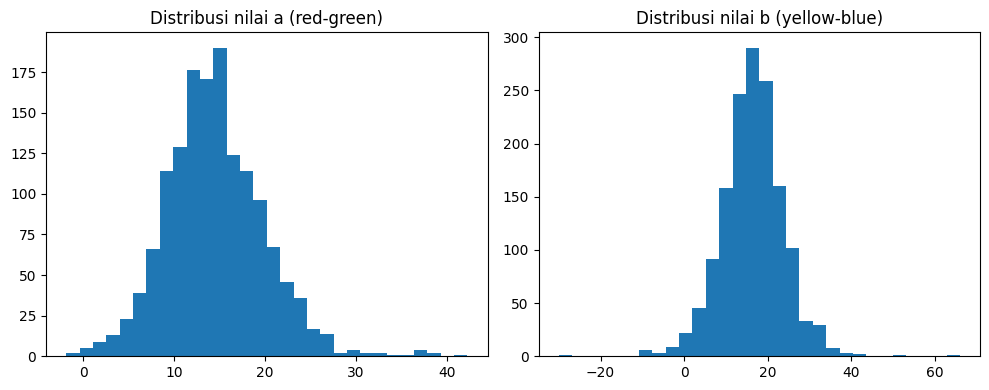

Statistik a_value:
 count    1470.000000
mean       14.538027
std         5.392025
min        -1.860000
25%        11.140000
50%        14.235000
75%        17.770000
max        42.270000
Name: a_value, dtype: float64

Statistik b_value:
 count    1470.000000
mean       16.339272
std         7.448728
min       -30.030000
25%        12.160000
50%        16.310000
75%        20.747500
max        66.050000
Name: b_value, dtype: float64


In [ ]:
# Cek sebaran nilai a & b dari hasil labeling ambang tetap
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df_labeled["a_value"], bins=30)
plt.title("Distribusi nilai a (red-green)")

plt.subplot(1, 2, 2)
plt.hist(df_labeled["b_value"], bins=30)
plt.title("Distribusi nilai b (yellow-blue)")
plt.tight_layout()
plt.show()

print("Statistik a_value:\n", df_labeled["a_value"].describe())
print("\nStatistik b_value:\n", df_labeled["b_value"].describe())


## Tahap 3b — Threshold Adaptif (Percentile) + Subsampling Seimbang

Supaya distribusi kelas tidak timpang dan sesuai dengan klaim di laporan (300 citra, 100/100/100, split 80:20), kita:
1. Hitung ulang ambang batas `warm`/`cool` berdasarkan **persentil ke-33 dan ke-66** dari selisih (b - a) pada data kalian sendiri
   (bukan angka tetap 8 dan -3 di Tahap 3) — ini membuat proporsi ketiga kelas jadi lebih seimbang secara alami.
2. Label ulang seluruh data pakai ambang baru ini.
3. Ambil sampel seimbang: 100 citra per kelas → total 300 citra, disimpan sebagai dataset final yang dipakai di seluruh tahap
   berikutnya (ekstraksi fitur, training classifier, evaluasi).

> **Catatan kejujuran metodologi:** kalau salah satu kelas hasilnya kurang dari 100 setelah relabeling, itu dilaporkan apa
> adanya di Bab IV (misalnya "diperoleh 290 citra karena keterbatasan distribusi warna pada dataset sumber") — jangan dipaksakan
> jadi tepat 300 kalau datanya memang tidak cukup, supaya laporan tetap bisa dipertanggungjawabkan.


In [ ]:
# 1) Hitung ambang batas adaptif dari persentil distribusi (b - a) pada data kalian sendiri
selisih_ab = df_labeled["b_value"] - df_labeled["a_value"]
ambang_cool_baru = selisih_ab.quantile(0.33)
ambang_warm_baru = selisih_ab.quantile(0.66)
print(f"Ambang adaptif -> cool jika selisih < {ambang_cool_baru:.2f} | warm jika selisih > {ambang_warm_baru:.2f}")


def klasifikasi_undertone_lab_v2(patch_rgb, ambang_warm=ambang_warm_baru, ambang_cool=ambang_cool_baru):
    """Versi adaptif: ambang batas mengikuti distribusi data, bukan angka tetap."""
    patch_bgr = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2BGR)
    patch_lab = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    a_mean = np.mean(patch_lab[:, :, 1]) - 128
    b_mean = np.mean(patch_lab[:, :, 2]) - 128
    selisih = b_mean - a_mean
    if selisih > ambang_warm:
        return "warm", a_mean, b_mean
    elif selisih < ambang_cool:
        return "cool", a_mean, b_mean
    else:
        return "neutral", a_mean, b_mean


# 2) Label ulang seluruh data pakai ambang adaptif
hasil_v2 = []
for _, row in df_labeled.iterrows():
    patch = ambil_area_kulit(row["filepath"])
    if patch is None or patch.size == 0:
        continue
    undertone, a_val, b_val = klasifikasi_undertone_lab_v2(patch)
    hasil_v2.append({
        "filepath": row["filepath"],
        "skintone_asli": row["skintone_asli"],
        "undertone": undertone,
        "a_value": round(float(a_val), 2),
        "b_value": round(float(b_val), 2),
    })

df_labeled_v2 = pd.DataFrame(hasil_v2)
print("Distribusi undertone setelah ambang adaptif:")
print(df_labeled_v2["undertone"].value_counts())


Ambang adaptif -> cool jika selisih < 0.03 | warm jika selisih > 3.80
Distribusi undertone setelah ambang adaptif:
undertone
warm       500
neutral    486
cool       484
Name: count, dtype: int64


In [ ]:
# 3) Subsampling seimbang: ambil maksimal 100 citra per kelas
JUMLAH_PER_KELAS = 100

df_final = (
    df_labeled_v2.groupby("undertone", group_keys=False)
    .apply(lambda g: g.sample(min(JUMLAH_PER_KELAS, len(g)), random_state=42))
    .reset_index(drop=True)
)

print("Dataset final (dipakai untuk ekstraksi fitur, training, dan evaluasi):")
print(df_final["undertone"].value_counts())
print("Total citra:", len(df_final))

df_final.to_csv("/content/dataset_final_300.csv", index=False)

# variabel ini dipakai di semua tahap berikutnya
df_labeled = df_final
contoh_path = df_labeled.iloc[0]["filepath"]
print("\ncontoh_path untuk pengujian fungsi-fungsi berikutnya:", contoh_path)


Dataset final (dipakai untuk ekstraksi fitur, training, dan evaluasi):
undertone
cool       100
neutral    100
warm       100
Name: count, dtype: int64
Total citra: 300

contoh_path untuk pengujian fungsi-fungsi berikutnya: /content/dataset/train/fair/94581230_jpg.rf.c52d66a9b3078902038f0f5664847e13.jpg


/tmp/ipykernel_542/1053773527.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(JUMLAH_PER_KELAS, len(g)), random_state=42))


## Tahap 4 — Ekstraksi Fitur Wajah dengan DINOv2

In [ ]:
from transformers import AutoImageProcessor, AutoModel

dinov2_processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
dinov2_model = AutoModel.from_pretrained("facebook/dinov2-base").to(device)
dinov2_model.eval()
print("DINOv2 berhasil dimuat.")

def ekstrak_fitur_dinov2(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = dinov2_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = dinov2_model(**inputs)
        fitur = outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()
    return fitur

# Contoh: ekstrak fitur dari 1 foto sample buat memastikan fungsinya jalan
fitur_contoh = ekstrak_fitur_dinov2(contoh_path)
print("Contoh path:", contoh_path)
print("Ukuran vector fitur:", fitur_contoh.shape)


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 berhasil dimuat.
Contoh path: /content/dataset/train/fair/94581230_jpg.rf.c52d66a9b3078902038f0f5664847e13.jpg
Ukuran vector fitur: (768,)


## Tahap 4b — Ekstraksi Fitur Massal (Seluruh Dataset Final)

Sebelumnya DINOv2 cuma dites di 1 foto contoh. Di sini kita ekstrak fitur untuk **seluruh 300 (atau kurang) citra**
di `df_final`, supaya bisa dipakai melatih classifier di Tahap 4.5.


In [ ]:
from tqdm import tqdm

X_fitur = []
y_label = []
filepath_valid = []

for _, row in tqdm(df_labeled.iterrows(), total=len(df_labeled), desc="Ekstraksi fitur DINOv2"):
    try:
        fitur = ekstrak_fitur_dinov2(row["filepath"])
        X_fitur.append(fitur)
        y_label.append(row["undertone"])
        filepath_valid.append(row["filepath"])
    except Exception as e:
        print("Gagal ekstrak:", row["filepath"], "-", e)

X_fitur = np.array(X_fitur)
y_label = np.array(y_label)

print("Bentuk matrix fitur X:", X_fitur.shape)
print("Jumlah label y:", len(y_label))

np.save("/content/X_fitur_dinov2.npy", X_fitur)
np.save("/content/y_label_undertone.npy", y_label)


Ekstraksi fitur DINOv2: 100%|██████████| 300/300 [00:09<00:00, 32.35it/s]

Bentuk matrix fitur X: (300, 768)
Jumlah label y: 300


## Tahap 4.5 — Training Classifier (Logistic Regression) di atas Fitur DINOv2

Bagian ini yang membuat klaim "split 80:20, evaluasi accuracy/precision/recall/F1-score" di laporan (Bab III) benar-benar
dilakukan di kode, bukan cuma dijanjikan di teks. DINOv2 dipakai sebagai ekstraktor fitur (feature extractor), lalu di atas
fitur itu dilatih classifier sederhana (Logistic Regression) untuk mengklasifikasi undertone secara langsung.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode label teks (warm/cool/neutral) jadi angka
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_label)
print("Kelas:", list(label_encoder.classes_))

# Split 80:20, stratify supaya proporsi tiap kelas tetap seimbang di train & test
X_train, X_test, y_train, y_test = train_test_split(
    X_fitur, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing :", X_test.shape[0])

# Standarisasi fitur (penting untuk Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Kelas: [np.str_('cool'), np.str_('neutral'), np.str_('warm')]
Jumlah data training: 240
Jumlah data testing : 60


In [ ]:
from sklearn.linear_model import LogisticRegression

clf_undertone = LogisticRegression(max_iter=2000, random_state=42)
clf_undertone.fit(X_train_scaled, y_train)
print("Training classifier selesai.")


Training classifier selesai.


Accuracy : 36.67%
Precision (macro): 36.53%
Recall (macro)   : 36.67%
F1-score (macro) : 36.49%

Classification Report lengkap per kelas:
              precision    recall  f1-score   support

        cool       0.39      0.45      0.42        20
     neutral       0.39      0.35      0.37        20
        warm       0.32      0.30      0.31        20

    accuracy                           0.37        60
   macro avg       0.37      0.37      0.36        60
weighted avg       0.37      0.37      0.36        60



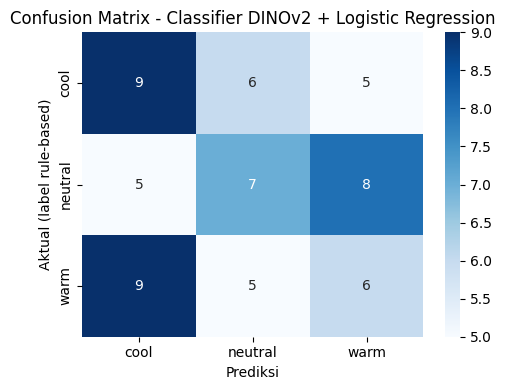

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns

y_pred = clf_undertone.predict(X_test_scaled)

akurasi = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")

print(f"Accuracy : {akurasi*100:.2f}%")
print(f"Precision (macro): {precision*100:.2f}%")
print(f"Recall (macro)   : {recall*100:.2f}%")
print(f"F1-score (macro) : {f1*100:.2f}%")
print()
print("Classification Report lengkap per kelas:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Prediksi")
plt.ylabel("Aktual (label rule-based)")
plt.title("Confusion Matrix - Classifier DINOv2 + Logistic Regression")
plt.tight_layout()
plt.show()


## Tahap 5 — Database Shade Lip Cream

In [ ]:
data_shade = [
    {"nama_shade": "Terracotta Red",   "hex": "#C1440E", "kategori_undertone": "warm",    "deskripsi": "warm terracotta red lip color with orange undertone"},
    {"nama_shade": "Golden Coral",     "hex": "#FF7F50", "kategori_undertone": "warm",    "deskripsi": "warm golden coral lip color, bright and peachy"},
    {"nama_shade": "Brick Orange",     "hex": "#C1440E", "kategori_undertone": "warm",    "deskripsi": "warm brick orange lip shade for tan skin"},
    {"nama_shade": "Honey Nude",       "hex": "#D2A679", "kategori_undertone": "warm",    "deskripsi": "warm honey nude lip color, natural everyday shade"},
    {"nama_shade": "Rosy Mauve",       "hex": "#B76E79", "kategori_undertone": "cool",    "deskripsi": "cool rosy mauve lip color with pink undertone"},
    {"nama_shade": "Berry Wine",       "hex": "#722F37", "kategori_undertone": "cool",    "deskripsi": "cool deep berry wine lip color, bold and elegant"},
    {"nama_shade": "Cool Pink",        "hex": "#E75480", "kategori_undertone": "cool",    "deskripsi": "cool bright pink lip color with blue undertone"},
    {"nama_shade": "Lavender Plum",    "hex": "#8E4585", "kategori_undertone": "cool",    "deskripsi": "cool lavender plum lip shade, purple toned"},
    {"nama_shade": "Nude Beige",       "hex": "#D2B48C", "kategori_undertone": "neutral", "deskripsi": "neutral nude beige lip color, balanced tone"},
    {"nama_shade": "Soft Rose",        "hex": "#C08081", "kategori_undertone": "neutral", "deskripsi": "neutral soft rose lip color, subtle everyday shade"},
    {"nama_shade": "Classic Red",      "hex": "#B22222", "kategori_undertone": "neutral", "deskripsi": "neutral classic red lip color, universally flattering"},
    {"nama_shade": "Mocha Brown",      "hex": "#8B5A2B", "kategori_undertone": "neutral", "deskripsi": "neutral mocha brown lip shade, warm-cool balanced"},
]

df_shade = pd.DataFrame(data_shade)
df_shade


,nama_shade,hex,kategori_undertone,deskripsi
0,Terracotta Red,#C1440E,warm,warm terracotta red lip color with orange unde...
1,Golden Coral,#FF7F50,warm,"warm golden coral lip color, bright and peachy"
2,Brick Orange,#C1440E,warm,warm brick orange lip shade for tan skin
3,Honey Nude,#D2A679,warm,"warm honey nude lip color, natural everyday shade"
4,Rosy Mauve,#B76E79,cool,cool rosy mauve lip color with pink undertone
5,Berry Wine,#722F37,cool,"cool deep berry wine lip color, bold and elegant"
6,Cool Pink,#E75480,cool,cool bright pink lip color with blue undertone
7,Lavender Plum,#8E4585,cool,"cool lavender plum lip shade, purple toned"
8,Nude Beige,#D2B48C,neutral,"neutral nude beige lip color, balanced tone"
9,Soft Rose,#C08081,neutral,"neutral soft rose lip color, subtle everyday s..."


## Tahap 6 — Prediksi Undertone & Matching Shade

Dua pendekatan dipakai berdampingan:
- **CLIP zero-shot**: dipakai di web app secara real-time (tidak perlu training ulang, cukup fleksibel untuk foto baru).
- **DINOv2 + Logistic Regression** (hasil Tahap 4.5): classifier terlatih, dipakai sebagai pembanding/validasi terhadap CLIP.


In [ ]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
print("CLIP berhasil dimuat.")


def prediksi_undertone_clip(image_path):
    image = Image.open(image_path).convert("RGB")
    label_teks = [
        "a photo of a face with warm undertone skin, yellow or golden hue",
        "a photo of a face with cool undertone skin, pink or blue hue",
        "a photo of a face with neutral undertone skin, balanced hue",
    ]
    kategori = ["warm", "cool", "neutral"]

    inputs = clip_processor(text=label_teks, images=image, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        outputs = clip_model(**inputs)
        skor = outputs.logits_per_image.softmax(dim=1).cpu().numpy().flatten()

    idx_terbaik = int(np.argmax(skor))
    return kategori[idx_terbaik], dict(zip(kategori, skor.round(3)))


def rekomendasi_shade(image_path, df_shade, top_n=3):
    undertone_terdeteksi, skor_undertone = prediksi_undertone_clip(image_path)
    print(f"Undertone terdeteksi (CLIP): {undertone_terdeteksi.upper()}  |  skor: {skor_undertone}")

    kandidat = df_shade[df_shade["kategori_undertone"] == undertone_terdeteksi].copy()

    image = Image.open(image_path).convert("RGB")
    inputs = clip_processor(text=list(kandidat["deskripsi"]), images=image, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        outputs = clip_model(**inputs)
        skor_shade = outputs.logits_per_image.softmax(dim=1).cpu().numpy().flatten()

    kandidat["skor_kecocokan"] = skor_shade
    hasil = kandidat.sort_values("skor_kecocokan", ascending=False).head(top_n)
    return undertone_terdeteksi, hasil

# Tes dengan salah satu foto dari dataset final
contoh_undertone, contoh_rekomendasi = rekomendasi_shade(contoh_path, df_shade)
contoh_rekomendasi


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP berhasil dimuat.
Undertone terdeteksi (CLIP): WARM  |  skor: {'warm': np.float32(0.522), 'cool': np.float32(0.103), 'neutral': np.float32(0.375)}


,nama_shade,hex,kategori_undertone,deskripsi,skor_kecocokan
2,Brick Orange,#C1440E,warm,warm brick orange lip shade for tan skin,0.422084
1,Golden Coral,#FF7F50,warm,"warm golden coral lip color, bright and peachy",0.276063
3,Honey Nude,#D2A679,warm,"warm honey nude lip color, natural everyday shade",0.169236


In [ ]:
def prediksi_undertone_dinov2(image_path):
    """
    Prediksi undertone pakai classifier terlatih (DINOv2 fitur + Logistic Regression).
    Dipakai sebagai pembanding terhadap hasil CLIP zero-shot (Tahap 9 - Validasi).
    """
    fitur = ekstrak_fitur_dinov2(image_path).reshape(1, -1)
    fitur_scaled = scaler.transform(fitur)
    pred_encoded = clf_undertone.predict(fitur_scaled)[0]
    pred_label = label_encoder.inverse_transform([pred_encoded])[0]
    proba = clf_undertone.predict_proba(fitur_scaled)[0]
    skor = dict(zip(label_encoder.classes_, proba.round(3)))
    return pred_label, skor

# Tes cepat pada foto yang sama
pred_dinov2, skor_dinov2 = prediksi_undertone_dinov2(contoh_path)
print(f"Undertone terdeteksi (DINOv2+LogReg): {pred_dinov2.upper()}  |  skor: {skor_dinov2}")


Undertone terdeteksi (DINOv2+LogReg): COOL  |  skor: {np.str_('cool'): np.float64(0.978), np.str_('neutral'): np.float64(0.016), np.str_('warm'): np.float64(0.006)}


## Tahap 7 — Simulasi Visual Shade di Bibir (Color Blend + Diffusion Model)

**Opsi A (default, dipakai di web app):** color blend berbasis deteksi wajah Haar Cascade — cepat & stabil, tidak butuh GPU besar.

**Opsi B (opsional, kalau waktu & GPU cukup):** diffusion inpainting pakai Stable Diffusion — lebih "AI-heavy" sesuai judul, tapi jauh lebih lambat.


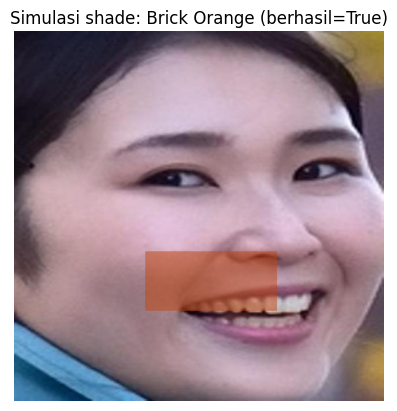

In [ ]:
def deteksi_area_bibir(image_path, min_ukuran_wajah_ratio=0.15):
    """
    Deteksi wajah pakai Haar Cascade, lalu perkirakan area bibir secara proporsional
    dari bounding box wajah. Ada validasi kualitas: kalau wajah tidak terdeteksi dengan baik
    (terlalu kecil / tidak ada), fungsi mengembalikan status "gagal".
    """
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    h, w, _ = image.shape

    wajah = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))

    if len(wajah) == 0:
        return image_rgb, None, False

    x, y, bw, bh = max(wajah, key=lambda box: box[2] * box[3])

    rasio_wajah = (bw * bh) / (w * h)
    if rasio_wajah < min_ukuran_wajah_ratio:
        return image_rgb, None, False

    lx1 = x + int(bw * 0.30)
    lx2 = x + int(bw * 0.70)
    ly1 = y + int(bh * 0.62)
    ly2 = y + int(bh * 0.80)

    lx1, ly1 = max(0, lx1), max(0, ly1)
    lx2, ly2 = min(w, lx2), min(h, ly2)

    if lx2 <= lx1 or ly2 <= ly1:
        return image_rgb, None, False

    return image_rgb, (lx1, ly1, lx2, ly2), True


def simulasi_shade_colorblend(image_path, hex_color, alpha=0.5):
    """
    Blend warna shade ke area bibir. Mengembalikan (gambar_hasil, berhasil_atau_tidak).
    Kalau wajah/bibir tidak terdeteksi dengan baik, gambar asli dikembalikan dengan
    status False supaya pemanggil (web app) bisa kasih peringatan ke user.
    """
    image_rgb, area_bibir_box, berhasil = deteksi_area_bibir(image_path)

    if not berhasil:
        return image_rgb, False

    lx1, ly1, lx2, ly2 = area_bibir_box
    warna_rgb = tuple(int(hex_color.lstrip("#")[i:i+2], 16) for i in (0, 2, 4))

    hasil = image_rgb.copy()
    area = hasil[ly1:ly2, lx1:lx2].astype(np.float32)
    warna_layer = np.full_like(area, warna_rgb, dtype=np.float32)
    area_blend = (area * (1 - alpha) + warna_layer * alpha).astype(np.uint8)
    hasil[ly1:ly2, lx1:lx2] = area_blend

    return hasil, True

# Tes color blend pada foto contoh dengan shade terbaik hasil rekomendasi CLIP
hasil_visual, ok = simulasi_shade_colorblend(contoh_path, contoh_rekomendasi.iloc[0]["hex"])
plt.imshow(hasil_visual)
plt.title(f"Simulasi shade: {contoh_rekomendasi.iloc[0]['nama_shade']} (berhasil={ok})")
plt.axis("off")
plt.show()


In [ ]:
# OPSI B - Diffusion inpainting, jalankan setelah opsi A (color blend) terbukti jalan lancar
from diffusers import StableDiffusionInpaintPipeline

def load_diffusion_pipeline():
    pipe = StableDiffusionInpaintPipeline.from_pretrained(
        "runwayml/stable-diffusion-inpainting",
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    ).to(device)
    return pipe

def simulasi_shade_diffusion(image_path, hex_color, pipe):
    """
    Diffusion inpainting: gambar ulang area bibir sesuai warna shade yang direkomendasikan.
    Mengembalikan (gambar_hasil, berhasil_atau_tidak) sama seperti versi color blend.
    """
    image = Image.open(image_path).convert("RGB").resize((512, 512))
    image.save("/content/_temp_resized.jpg")
    image_rgb, area_bibir_box, berhasil = deteksi_area_bibir("/content/_temp_resized.jpg")
    w, h = image.size

    if not berhasil:
        return image, False

    lx1, ly1, lx2, ly2 = area_bibir_box
    mask_np = np.zeros((h, w), dtype=np.uint8)
    pusat = ((lx1 + lx2) // 2, (ly1 + ly2) // 2)
    sumbu = ((lx2 - lx1) // 2, (ly2 - ly1) // 2)
    cv2.ellipse(mask_np, pusat, sumbu, 0, 0, 360, 255, -1)
    mask_img = Image.fromarray(mask_np)

    prompt = f"lips with {hex_color} lip cream color, natural skin, photorealistic"
    hasil_diffusion = pipe(prompt=prompt, image=image, mask_image=mask_img, num_inference_steps=25).images[0]
    return hasil_diffusion, True

# pipe_diffusion = load_diffusion_pipeline()
# hasil, ok = simulasi_shade_diffusion(contoh_path, contoh_rekomendasi.iloc[0]["hex"], pipe_diffusion)
# hasil


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## Tahap 8 — Web App dengan Gradio

In [ ]:
import gradio as gr
import tempfile

def pipeline_lengkap(foto_user):
    temp_path = tempfile.NamedTemporaryFile(suffix=".jpg", delete=False).name
    foto_user.save(temp_path)

    undertone_clip, rekomendasi = rekomendasi_shade(temp_path, df_shade, top_n=3)
    undertone_dinov2, skor_dinov2 = prediksi_undertone_dinov2(temp_path)
    shade_terbaik = rekomendasi.iloc[0]
    hasil_visual, berhasil = simulasi_shade_colorblend(temp_path, shade_terbaik["hex"])

    teks_hasil = f"### Undertone terdeteksi (CLIP): **{undertone_clip.upper()}**\n"
    teks_hasil += f"### Undertone terdeteksi (DINOv2 + LogReg): **{undertone_dinov2.upper()}**\n\n"
    teks_hasil += "**Rekomendasi shade (berdasarkan hasil CLIP):**\n\n"
    for _, row in rekomendasi.iterrows():
        teks_hasil += f"- {row['nama_shade']} ({row['hex']}) — skor kecocokan: {row['skor_kecocokan']:.3f}\n"

    if not berhasil:
        teks_hasil += "\n\n⚠️ **Catatan:** wajah tidak terdeteksi dengan jelas di foto ini, simulasi visual bibir mungkin kurang akurat. Coba upload foto wajah frontal dengan pencahayaan cukup, tanpa aksesoris yang menutupi wajah."

    return teks_hasil, Image.fromarray(hasil_visual) if isinstance(hasil_visual, np.ndarray) else hasil_visual


with gr.Blocks(title="Rekomendasi Shade Lip Cream") as demo:
    gr.Markdown("# \U0001F484 Rekomendasi Shade Lip Cream Berbasis Undertone Kulit Wajah")
    gr.Markdown("Upload foto wajah (tampak depan, pencahayaan cukup, wajah tidak tertutup aksesoris) untuk dapat rekomendasi shade & simulasi visual.")

    with gr.Row():
        input_foto = gr.Image(type="pil", label="Upload Foto Wajah")
        with gr.Column():
            output_teks = gr.Markdown(label="Hasil Rekomendasi")
            output_gambar = gr.Image(label="Simulasi Visual")

    tombol = gr.Button("Proses")
    tombol.click(fn=pipeline_lengkap, inputs=input_foto, outputs=[output_teks, output_gambar])

demo.launch(share=True, debug=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3b7c332f7a68ba81d6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.


KeyboardInterrupt: 

## Tahap 9 — Validasi & Perbandingan Tiga Pendekatan

Membandingkan tiga cara menentukan undertone pada sample data yang sama:
1. **Rule-based** (label acuan/ground truth versi penelitian ini, dari Tahap 3b)
2. **CLIP zero-shot** (Tahap 6)
3. **DINOv2 + Logistic Regression** (Tahap 4.5 & 6)

Bagian ini bagus dicantumkan di Bab IV "Hasil dan Pembahasan" untuk menunjukkan konsistensi antar-pendekatan, sekaligus
menjadi bukti bahwa metrik accuracy/precision/recall/F1 yang dijanjikan di Bab III benar-benar dihitung (lihat juga output
Tahap 4.5 di atas untuk metrik formal classifier).


In [ ]:
import random

# Ambil sample kecil (misal 20 foto) dari dataset final untuk dibandingkan
sample_df = df_labeled.sample(min(20, len(df_labeled)), random_state=42)

hasil_validasi = []
for _, row in sample_df.iterrows():
    pred_clip, _ = prediksi_undertone_clip(row["filepath"])
    pred_dinov2, _ = prediksi_undertone_dinov2(row["filepath"])
    hasil_validasi.append({
        "filepath": row["filepath"],
        "undertone_rulebased": row["undertone"],
        "undertone_clip": pred_clip,
        "undertone_dinov2_logreg": pred_dinov2,
        "clip_sama_rulebased": row["undertone"] == pred_clip,
        "dinov2_sama_rulebased": row["undertone"] == pred_dinov2,
    })

df_validasi = pd.DataFrame(hasil_validasi)
print(f"Kecocokan CLIP vs rule-based       : {df_validasi['clip_sama_rulebased'].mean()*100:.1f}%")
print(f"Kecocokan DINOv2+LogReg vs rule-based: {df_validasi['dinov2_sama_rulebased'].mean()*100:.1f}%")
df_validasi


---
### Catatan Penting Sebelum Presentasi / Submit

- Jalankan **Tahap 1 → 9 berurutan dari atas**, jangan loncat — tahap belakang bergantung ke variabel yang dibuat di tahap
  sebelumnya (`df_labeled`, `df_final`, `df_shade`, `contoh_path`, `X_fitur`, `clf_undertone`, `scaler`, `label_encoder`, dll).
- Tahap 3b (threshold adaptif + subsampling) adalah kunci supaya dataset final 300 citra (100/100/100) benar-benar konsisten
  dengan yang ditulis di laporan (Bab I & Bab IV).
- Tahap 4.5 (training classifier) adalah kunci supaya klaim "split 80:20, accuracy/precision/recall/F1-score" di Bab III
  benar-benar punya bukti kode, bukan cuma teks.
- Jelaskan di laporan bahwa label undertone berasal dari **rule-based LAB color space** (bukan anotasi pakar profesional),
  sebagai keterbatasan penelitian yang diakui secara transparan.
- Opsi diffusion (Tahap 7B) itu **opsional** — prioritaskan pastikan Tahap 1-8 dengan opsi A (color blend) sudah jalan
  lancar dulu sebelum mencoba opsi B.
- Tahap 9 (validasi) + output metrik Tahap 4.5 adalah bahan utama untuk bagian "Hasil dan Pembahasan" di laporan/jurnal kalian.
